In [195]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [196]:
from gates.data.load_data import LoadSquareSatelliteData, LoadReceptorData, load_fps
from gates.data.datasets import get_square_satellite_inputs_v2

In [197]:
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt
import datetime
import pandas as pd


## hello! you can load some footprints using the load_fps function. it should work for both .nc and .zarr footprints

In [198]:
load_fps("/somepath/GOSAT-SAHARA-column_NORTHAFRICA_2014.zarr")

<xarray.Dataset> Size: 4GB
Dimensions:      (lat: 240, lon: 391, time: 11485, height: 20, lev: 1)
Coordinates:
  * height       (height) float32 80B 500.0 1.5e+03 ... 1.85e+04 1.95e+04
  * lat          (lat) float32 960B -15.0 -14.77 -14.53 ... 40.46 40.69 40.93
  * lev          (lev) |S1 1B b'c'
  * lon          (lon) float32 2kB -50.0 -49.65 -49.3 ... 86.58 86.93 87.28
  * time         (time) datetime64[ns] 92kB 2014-01-01T11:01:16 ... 2014-12-1...
Data variables:
    fp           (lat, lon, time) float32 4GB dask.array<chunksize=(240, 391, 100), meta=np.ndarray>
    release_lat  (time) float32 46kB dask.array<chunksize=(100,), meta=np.ndarray>
    release_lon  (time) float32 46kB dask.array<chunksize=(100,), meta=np.ndarray>
Attributes:
    author:     lw13938
    created:    2019-09-02 18:53:14.338880
    max_level:  17

the data object should load all the components from the paths you specified in config. By default, the met is loaded from a zarr store, the footprint format can be chosen with `fp_format="zarr"` or `fp_format="nc"`

In [205]:
data = LoadSquareSatelliteData(2014, month="01", freq=3, size=50, region="SAHARA", fp_format="zarr", verbose=True, fill_outofdomain_with="nans", crop_met=True)

2024.5.2
---- LOADING FOOTPRINTS
Loading footprint data from /gws/ssde/j25b/acrg/elenafi/zarr_footprints/NORTHAFRICA/*SAHARA*NORTHAFRICA_2014*.zarr
Loading footprints from 1 zarr store(s): ['/gws/ssde/j25b/acrg/elenafi/zarr_footprints/NORTHAFRICA/GOSAT-SAHARA-column_NORTHAFRICA_2014.zarr']
reduced the number of datapoints by frequency 3
Loading 381 footprints
loaded fp variable into mem
----- Cutting footprints to square of size 50
Padding lat by (0, 12) cells (S, N) with mode='nans'

 ---- LOADING MET
Loading meteorology from /gws/ssde/j25b/acrg/elenafi/satellite_met_zarr/NORTHAFRICA/NORTHAFRICA_Met_2014*.zarr


/home/users/elenafi/GATES_LPDM_emulator/gates/data/load_data.py:618: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  met_file = xr.open_mfdataset(


Dataset size (GB): 0.939632836

---- LOADING TOPOG AND LANDCOVER
Loading topography from /gws/ssde/j25b/acrg/elenafi/GATES_data/topog.nc
Loading landcover from /gws/ssde/j25b/acrg/elenafi/GATES_data/land_cover.nc
loading both into memory
----- Cutting topog
----- Cutting met
Graph build: 0.01s
met_unique has chunks Frozen({'lat': (296,), 'lon': (320,), 'time': (1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1), 'levels': (3,)}) and size 155.34 MB
Tasks in graph: 4846
Tasks after rechunk: 4855
computing met unique!
calculated wind_angle and wind_speed from x_wind and y_wind
---- All done!


In [206]:
%%time
data.met.load()

CPU times: user 9.16 s, sys: 485 ms, total: 9.64 s
Wall time: 7.37 s


<xarray.Dataset> Size: 61MB
Dimensions:                               (sample_id: 381, lat: 50, lon: 50,
                                           levels: 3, time_delta: 1)
Coordinates:
    dim_0                                 (sample_id) int64 3kB 4 4 ... 244 244
    forecast_period                       (sample_id) timedelta64[ns] 3kB 00:...
    forecast_reference_time               (sample_id) datetime64[ns] 3kB 2014...
  * lat                                   (lat) int64 400B 0 1 2 3 ... 47 48 49
    level_height                          (levels) float32 12B 10.0 ... 1.597...
  * levels                                (levels) int32 12B 1 9 15
  * lon                                   (lon) int64 400B 0 1 2 3 ... 47 48 49
    sigma                                 (levels) float32 12B 0.9989 ... 0.8264
  * sample_id                             (sample_id) int64 3kB 1 4 ... 1141
    fp_time                               (sample_id) datetime64[ns] 3kB 2014...
    met_timestamps                        (sample_id) datetime64[ns] 3kB 2014...
  * time_delta                            (time_delta) int64 8B 0
Data variables:
    atmosphere_boundary_layer_thickness   (sample_id, lat, lon) float32 4MB 1...
    atmosphere_downward_eastward_stress   (sample_id, lat, lon) float32 4MB -...
    atmosphere_downward_northward_stress  (sample_id, lat, lon) float32 4MB -...
    surface_upward_sensible_heat_flux     (sample_id, lat, lon) float32 4MB 1...
    x_wind                                (levels, sample_id, lat, lon) float32 11MB ...
    y_wind                                (levels, sample_id, lat, lon) float32 11MB ...
    lat_coords                            (sample_id, lat) float32 76kB 25.01...
    lon_coords                            (sample_id, lon) float32 76kB 23.92...
    wind_angle                            (levels, sample_id, lat, lon) float32 11MB ...
    wind_speed                            (levels, sample_id, lat, lon) float32 11MB ...
Attributes: (12/26)
    delta_lat:            0.23399999737739563
    delta_lon:            0.35199999809265137
    Conventions:          CF-1.10
    title:                UM meteorology, NORTHAFRICA 2014
    institution:          University of Bristol, Atmospheric Chemistry Resear...
    source:               Met Office Unified Model (UM) Mk7, extracted from t...
    ...                   ...
    zarr_chunks:          {'time': 1, 'lat': -1, 'lon': -1, 'levels': 3}
    months_present:       ['01']
    n_months_present:     1
    missing_months:       ['02', '03', '04', '05', '06', '07', '08', '09', '1...
    year_complete:        False
    native_canonical_mk:  n/a

In [207]:
data.met

<xarray.Dataset> Size: 61MB
Dimensions:                               (sample_id: 381, lat: 50, lon: 50,
                                           levels: 3, time_delta: 1)
Coordinates:
    dim_0                                 (sample_id) int64 3kB 4 4 ... 244 244
    forecast_period                       (sample_id) timedelta64[ns] 3kB 00:...
    forecast_reference_time               (sample_id) datetime64[ns] 3kB 2014...
  * lat                                   (lat) int64 400B 0 1 2 3 ... 47 48 49
    level_height                          (levels) float32 12B 10.0 ... 1.597...
  * levels                                (levels) int32 12B 1 9 15
  * lon                                   (lon) int64 400B 0 1 2 3 ... 47 48 49
    sigma                                 (levels) float32 12B 0.9989 ... 0.8264
  * sample_id                             (sample_id) int64 3kB 1 4 ... 1141
    fp_time                               (sample_id) datetime64[ns] 3kB 2014...
    met_timestamps                        (sample_id) datetime64[ns] 3kB 2014...
  * time_delta                            (time_delta) int64 8B 0
Data variables:
    atmosphere_boundary_layer_thickness   (sample_id, lat, lon) float32 4MB 1...
    atmosphere_downward_eastward_stress   (sample_id, lat, lon) float32 4MB -...
    atmosphere_downward_northward_stress  (sample_id, lat, lon) float32 4MB -...
    surface_upward_sensible_heat_flux     (sample_id, lat, lon) float32 4MB 1...
    x_wind                                (levels, sample_id, lat, lon) float32 11MB ...
    y_wind                                (levels, sample_id, lat, lon) float32 11MB ...
    lat_coords                            (sample_id, lat) float32 76kB 25.01...
    lon_coords                            (sample_id, lon) float32 76kB 23.92...
    wind_angle                            (levels, sample_id, lat, lon) float32 11MB ...
    wind_speed                            (levels, sample_id, lat, lon) float32 11MB ...
Attributes: (12/26)
    delta_lat:            0.23399999737739563
    delta_lon:            0.35199999809265137
    Conventions:          CF-1.10
    title:                UM meteorology, NORTHAFRICA 2014
    institution:          University of Bristol, Atmospheric Chemistry Resear...
    source:               Met Office Unified Model (UM) Mk7, extracted from t...
    ...                   ...
    zarr_chunks:          {'time': 1, 'lat': -1, 'lon': -1, 'levels': 3}
    months_present:       ['01']
    n_months_present:     1
    missing_months:       ['02', '03', '04', '05', '06', '07', '08', '09', '1...
    year_complete:        False
    native_canonical_mk:  n/a

<xarray.Dataset> Size: 4MB
Dimensions:      (sample_id: 381, lat: 50, lon: 50)
Coordinates:
  * lat          (lat) int64 400B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
  * lon          (lon) int64 400B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
  * sample_id    (sample_id) int64 3kB 1 4 7 10 13 ... 1129 1132 1135 1138 1141
    time         (sample_id) datetime64[ns] 3kB 2014-01-01T11:01:16 ... 2014-...
Data variables:
    fp           (sample_id, lat, lon) float32 4MB 0.0001068 ... 7.629e-06
    lat_coords   (sample_id, lat) float64 152kB 25.01 25.25 25.48 ... 20.8 21.04
    lon_coords   (sample_id, lon) float32 76kB 23.92 24.27 24.62 ... 12.3 12.66
    release_lat  (sample_id) float32 2kB 30.78 29.74 28.0 ... 22.98 20.86 15.41
    release_lon  (sample_id) float32 2kB 32.69 31.22 31.59 ... 5.84 2.736 4.125
Attributes:
    author:     lw13938
    created:    2019-09-02 18:53:14.338880
    max_level:  17

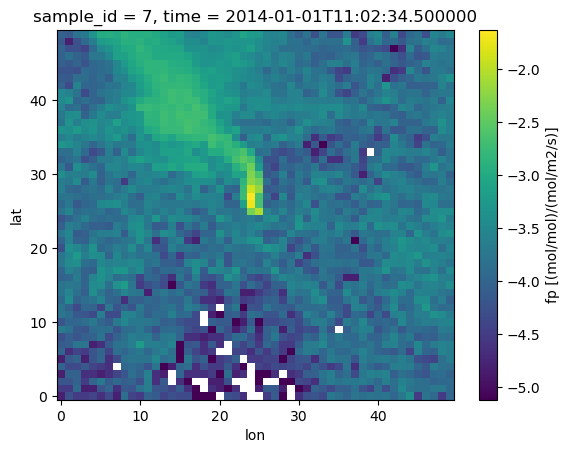

In [212]:
## the cropped data is stored in this attribute, as an array with dimensions (sample_dim, lat, lon) where sample_dim is a unique identifier
i= 2
np.log10(data.fp_xr.fp.isel(sample_id=i)).plot()
data.fp_xr

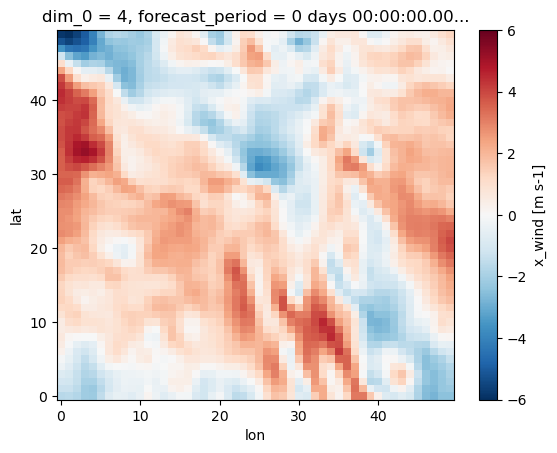

In [214]:
data.met.isel(sample_id=i,levels=0).x_wind.plot()

## testing the whole pipeline

In [23]:
# load data and some test data
data = LoadSquareSatelliteData(201604, freq=3, size=50, region="SAHARA", verbose=True, fill_outofdomain_with="nans")

data_test = LoadSquareSatelliteData(201609, freq=3, size=50, region="SAHARA", verbose=True, fill_outofdomain_with="nans")

2024.5.2
found nc footprints matching /gws/ssde/j25b/acrg/elenafi/example_footprints/NORTHAFRICA/*SAHARA*NORTHAFRICA_201604*.nc
---- LOADING FOOTPRINTS
Loading footprint data from /gws/ssde/j25b/acrg/elenafi/example_footprints/NORTHAFRICA/*SAHARA*NORTHAFRICA_201604*.nc
WITH CHUNKING -
reduced the number of datapoints by frequency 3
Loading 297 footprints
loaded fp variable into mem
----- Cutting footprints to square of size 50
Padding lat by (0, 12) cells (S, N) with mode='nans'

---- LOADING TOPOG AND LANDCOVER
Loading topography from /gws/ssde/j25b/acrg/elenafi/GATES_data/topog.nc
Loading landcover from /gws/ssde/j25b/acrg/elenafi/GATES_data/land_cover.nc
loading both into memory
----- Cutting topog
---- All done!
2024.5.2
found nc footprints matching /gws/ssde/j25b/acrg/elenafi/example_footprints/NORTHAFRICA/*SAHARA*NORTHAFRICA_201609*.nc
---- LOADING FOOTPRINTS
Loading footprint data from /gws/ssde/j25b/acrg/elenafi/example_footprints/NORTHAFRICA/*SAHARA*NORTHAFRICA_201609*.nc
WITH

In [7]:
# the footprints are stored in data.fp_xr
data.fp_xr

<xarray.Dataset> Size: 3MB
Dimensions:      (time: 297, lat: 50, lon: 50)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2016-04-01T12:02:40 ... 2016-04-30...
  * lon          (lon) int64 400B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
  * lat          (lat) int64 400B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
Data variables:
    fp           (time, lat, lon) float32 3MB dask.array<chunksize=(100, 50, 50), meta=np.ndarray>
    lat_coords   (time, lat) float64 119kB dask.array<chunksize=(100, 50), meta=np.ndarray>
    lon_coords   (time, lon) float32 59kB dask.array<chunksize=(100, 50), meta=np.ndarray>
    release_lat  (time) float32 1kB dask.array<chunksize=(100,), meta=np.ndarray>
    release_lon  (time) float32 1kB dask.array<chunksize=(100,), meta=np.ndarray>
Attributes:
    max_level:  17
    author:     lw13938
    created:    2020-01-22 17:05:32.659151

In [215]:
## choose the input variables as a dict, containing 1) a list of met variables (both 2D and 3D) to be extracted at 2) certain levels, 
# plus 3) a list of static variables to be appended and 4) the time lag on the met variables
met_params = {
        "met_variables":["x_wind", "y_wind", "atmosphere_boundary_layer_thickness"],
        "met_levels":[1, 9],
        "static_variables":["sin_lat_coords", "sin_lon_coords", "cos_lat_coords", "cos_lon_coords", "y_coords", "xy_distance_centre", "topog", "land_cover"], 
        "time_deltas":[6]
    }

In [216]:
# load the inputs. they will still be arranged along the sample_dim dimension
inputs, data = get_square_satellite_inputs_v2(data, **met_params)

------------------------
---EXTRACTING MET DATA (v2)---
Time deltas: [0, 6]
Met variables: ['x_wind', 'y_wind', 'atmosphere_boundary_layer_thickness']
Met levels: [1, 9]
Selecting 82 unique met timestamps 
First few unique timestamps: [numpy.datetime64('2014-01-01T06:00:00.000000000'), numpy.datetime64('2014-01-01T12:00:00.000000000'), numpy.datetime64('2014-01-02T06:00:00.000000000')] ...
Setting up met_with_levels: ['x_wind', 'y_wind']
Setting up surface_met: ['atmosphere_boundary_layer_thickness']
Setting up static: ['sin_lat_coords', 'sin_lon_coords', 'cos_lat_coords', 'cos_lon_coords', 'x_coords', 'xy_distance_centre', 'topog']
loading stadcked static into memory


/home/users/elenafi/GATES_LPDM_emulator/gates/data/datasets.py:1328: UserWarning: variable land_cover was not found and will be skipped
  static_ds = static_variables_functions[var](data.fp_data_full, static_ds)


In [217]:
inputs

<xarray.DataArray 'stacked_met_with_levels' (sample_id: 381, lat: 50, lon: 50,
                                             variable_name: 17)> Size: 65MB
dask.array<astype, shape=(381, 50, 50, 17), dtype=float32, chunksize=(381, 50, 50, 7), chunktype=numpy.ndarray>
Coordinates:
  * lat            (lat) int64 400B 0 1 2 3 4 5 6 7 ... 42 43 44 45 46 47 48 49
  * lon            (lon) int64 400B 0 1 2 3 4 5 6 7 ... 42 43 44 45 46 47 48 49
  * sample_id      (sample_id) int64 3kB 1 4 7 10 13 ... 1132 1135 1138 1141
    fp_time        (sample_id) datetime64[ns] 3kB 2014-01-01T11:01:16 ... 201...
    time           (sample_id) datetime64[ns] 3kB 2014-01-01T11:01:16 ... 201...
  * variable_name  (variable_name) object 136B MultiIndex
  * variable       (variable_name) object 136B 'x_wind' 'x_wind' ... 'topog'
  * levels         (variable_name) int64 136B 1 1 9 9 1 1 9 9 0 0 0 0 0 0 0 0 0
  * time_delta     (variable_name) int64 136B 0 6 0 6 0 6 0 6 0 6 0 0 0 0 0 0 0
Attributes:
    source:        Data from Met Office Unified Model
    time_deltas:   [0, 6]
    generated on:  2026-07-17 14:46:46.826262

In [10]:
#and the same for the test data
test_inputs, data_test = get_square_satellite_inputs(data_test, **met_params)

------------------------
---EXTRACTING MET DATA---
Time deltas: [0, 6]
extracting met at t-H for H in: [0, 6]
calculated wind_angle and wind_speed from x_wind and y_wind
Setting up met_with_levels: ['x_wind', 'y_wind', 'wind_speed', 'wind_angle']
Setting up surface_met: ['atmosphere_boundary_layer_thickness', 'surface_air_pressure']
Setting up static: ['lat_coords', 'lon_coords', 'y_coords', 'x_coords', 'topog']


/user/work/ef17148/GCN/graphnet/graphnet_LPDM_emulator/notebooks/../../graphnet_LPDM_emulator/model/data/datasets.py:600: UserWarning: variable distance_centre was not found in the list of known functions and will be skipped
  warnings.warn(f"variable {var} was not found in the list of known functions and will be skipped")


In [218]:
import gates.data.datasets as gates_datasets

In [219]:
# first normalize the inputs 
# we fit the scaler on a subsample of the data to speed up the process
inputs_dataset = gates_datasets.InputsDataset(inputs, scaler=gates_datasets.DefaultInputsScaler,  verbose=True ) #scaler_params={"fit_on_subsample": 0.5, "verbose": True}, verbose=True )
inputs_dataset.fit()
# then apply transform to the test set
inputs_scaled = inputs_dataset.transform(inputs)
#test_inputs_scaled = inputs_dataset.transform(test_inputs)

fitting standardise scaler for var x_wind
      at level 1
Computing mean and std for scaler...
      at level 9
Computing mean and std for scaler...
fitting standardise scaler for var y_wind
      at level 1
Computing mean and std for scaler...
      at level 9
Computing mean and std for scaler...
fitting standardise scaler for var atmosphere_boundary_layer_thickness
      at level 0
Computing mean and std for scaler...
fitting minmax scaler for var sin_lat_coords
Computing min for scaler...
min: 0.16625246
Computing max for scaler...
max: 0.6913113
fitting minmax scaler for var sin_lon_coords
Computing min for scaler...
min: -0.40034905
Computing max for scaler...
max: 0.6765676
fitting minmax scaler for var cos_lat_coords
Computing min for scaler...
min: 0.72255707
Computing max for scaler...
max: 0.9860832
fitting minmax scaler for var cos_lon_coords
Computing min for scaler...
min: 0.7363805
Computing max for scaler...
max: 0.99999994
fitting minmax scaler for var x_coords
Computi

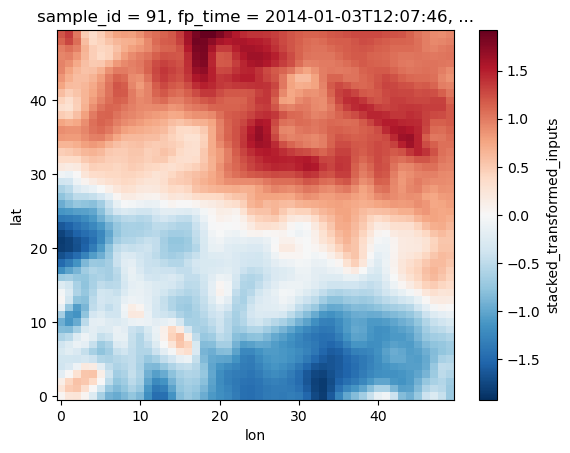

In [220]:
# the inputs, and the scaled inputs, store the data as a stacked array, 
# stacked along the variable_name dimension with shape (variable_name, levels, delta_time)
# e.g. we can plot the x_wind at level 3 for a particular timepoint, at delta_time = 0 and at delta_time = 6 (below)
# it will take a bit to load, it's doing the calculation on the fly!
# the same data could be selected with test_inputs_scaled.sel(variable="wind_speed", level=3, delta_time=0) or test_inputs_scaled.sel(variable="wind_speed", level=3, delta_time=6)
inputs_scaled.sel(variable_name= ('x_wind', 1, 0)).isel(sample_id=30).plot()
plt.show()
#inputs_scaled.sel(variable_name= ('x_wind', 1, 6)).isel(fp_time=0).plot()

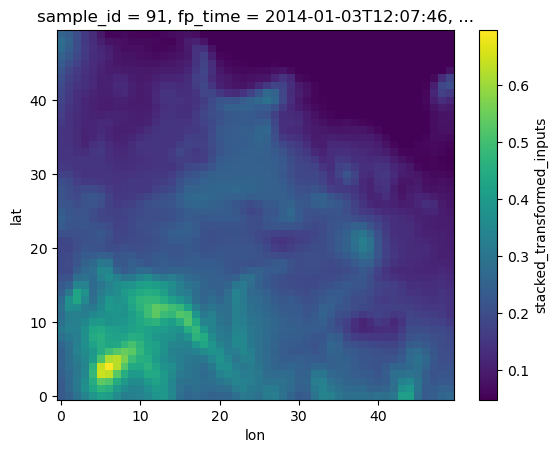

In [221]:
inputs_scaled.sel(variable = 'topog').isel(sample_id=30).plot()

In [222]:
# we can also transform the footprints
# for example, apply a log and shift scaler, which is common for footprint data, to make the distribution more normal and easier to learn from
fpds = gates_datasets.FootprintDataset(data.fp_xr, scaler=gates_datasets.LogAndShiftFpScaler, scaler_params={"minimum_oom":6})
transformed_fps = fpds.fit_transform()

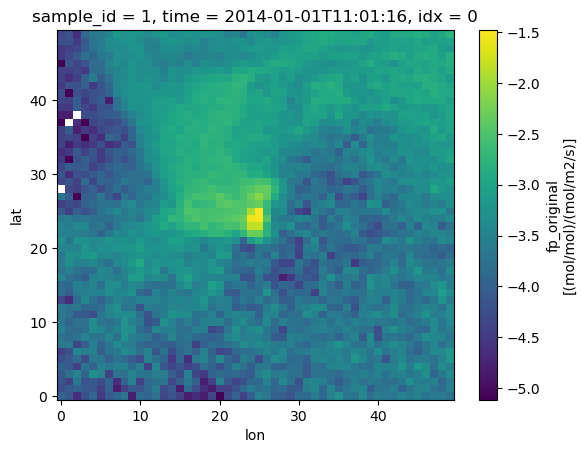

In [223]:
t_idx = 0
#t = transformed_fps.fp_transformed.isel(time=t_idx)
t = np.log10(transformed_fps.fp_original.isel(sample_id=t_idx))
t.plot()

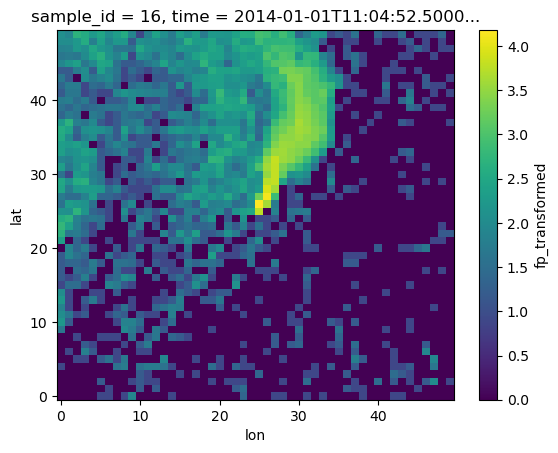

In [224]:
transformed_fps.fp_transformed.isel(sample_id=5).plot()

In [16]:
transformed_fps_test = fpds.transform(data_test.fp_xr)
# we can also inverse transform the footprints back to the original space if needed, e.g. for plotting or evaluation
inverse_transformed_fp = fpds.inverse_transform(transformed_fps_test.fp_transformed)

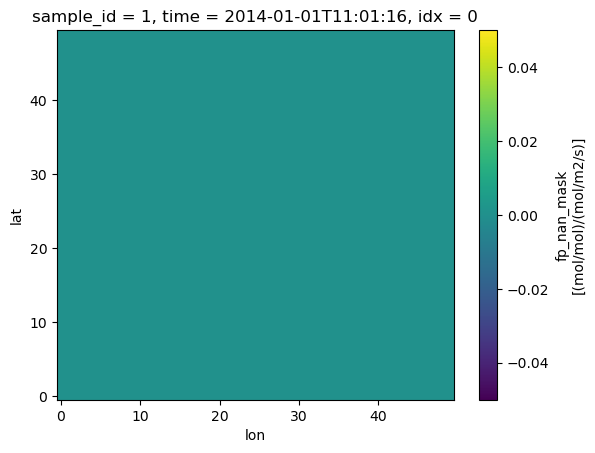

In [225]:
# if we pass add_nan_mask=True to the FootprintDataset, it will also add a mask indicating where the original footprints had nans, which can be useful to calculate the loss function avoiding areas where the footprints are not valid
fpds = gates_datasets.FootprintDataset(data.fp_xr, scaler=gates_datasets.LogAndShiftFpScaler, scaler_params={"minimum_oom": 6}, add_nan_mask=True)
transformed_fps = fpds.fit_transform()
transformed_fps.fp_nan_mask.isel(sample_id=0).plot()

### setting up an xbatcher

In [228]:
## the dataloader is created from an inputs array (stacked along the variable_name coord) and a footprints array OR dataset, and will return batches of inputs and footprints for training the model. randomize=True will shuffle the data, which is usually recommended for training

# we use the following params so it runs quickly on a notebook - no parallel processes (num_workers=0) and no prefetching (prefetch_factor=None). prefetch_factor indicates the number of batches to load in the background following the current batch, to speed up training
dataloader_params={"prefetch_factor": None, "num_workers": 0}

# here, transformed_fps.fp_transformed is a DataArray, so the dataloader will return batches of inputs and footprints 
train_dataloader, fp_labels = gates_datasets.make_dataloader(inputs_scaled, transformed_fps.fp_transformed, batch_size=3, randomize=False, dataloader_params=dataloader_params)

ValueError: chunks keys ('time',) not found in data dimensions ('lat', 'lon', 'sample_id')

In [26]:
train_features, train_footprints = next(iter(train_dataloader))
print(f"shape of train_features: {train_features.shape} \nshape of train_footprints: {train_footprints.shape} with labels {fp_labels}")

shape of train_features: torch.Size([3, 50, 50, 33]) 
shape of train_footprints: torch.Size([3, 50, 50]) with labels ['fp_transformed']


In [227]:
# alternatively, we can pass a dataset (transformed_fps has variables fp_transformed, fp_original and fp_nan_mask) and the returned footprints will have as many dimensions as the dataset variables
train_dataloader, fp_labels = gates_datasets.make_dataloader(inputs_scaled, transformed_fps, batch_size=3, randomize=False, dataloader_params=dataloader_params)
train_features, train_footprints = next(iter(train_dataloader))
print(f"shape of train_features: {train_features.shape} \nshape of train_footprints: {train_footprints.shape} with labels {fp_labels}")

you passed a fps dataset with multiple variables: ['fp_transformed', 'fp_original', 'fp_nan_mask']. All variables will be returned in the dataloader along a new dimension. 


ValueError: Variables in the dataset must contain all ``sample_dims`` (['time', 'lat', 'lon']) but 'fp_transformed' misses ['time']